# Application Train EDA - Home Credit Default Risk

This notebook performs exploratory data analysis on the `application_train.csv` file.

The objective is to understand which applicant characteristics are associated with repayment difficulty.

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
app_train=pd.read_csv("../data/raw/application_train.csv")
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
target = "TARGET"

default_rate = app_train[target].mean()
print(f"Default Rate: {default_rate:.2%}")


Default Rate: 8.07%


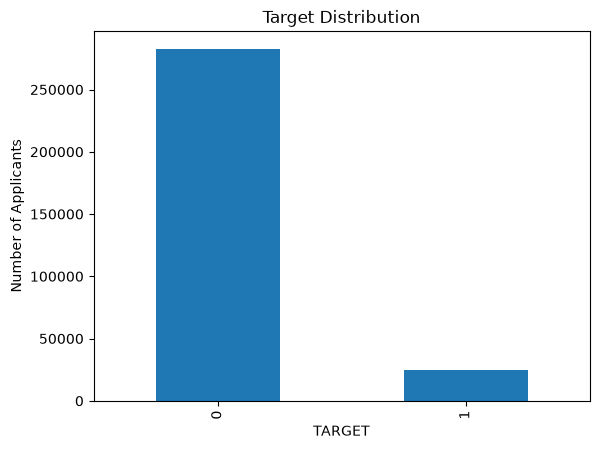

In [28]:
app_train[target].value_counts().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("TARGET")
plt.ylabel("Number of Applicants")
plt.show()

In [29]:
contract_default = app_train.groupby("NAME_CONTRACT_TYPE")[target].mean().sort_values(ascending=False)

contract_default

NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783
Name: TARGET, dtype: float64

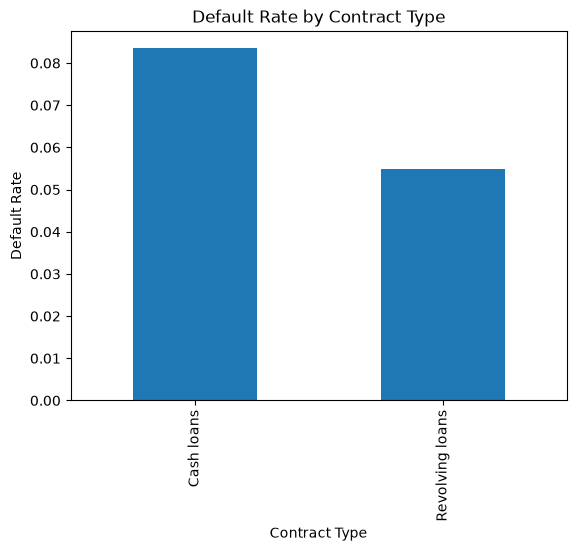

In [30]:
contract_default.plot(kind="bar")

plt.title("Default Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Default Rate")
plt.show()

In [31]:
gender_default = app_train.groupby("CODE_GENDER")[target].mean().sort_values(ascending=False)

gender_default

CODE_GENDER
M      0.101419
F      0.069993
XNA    0.000000
Name: TARGET, dtype: float64

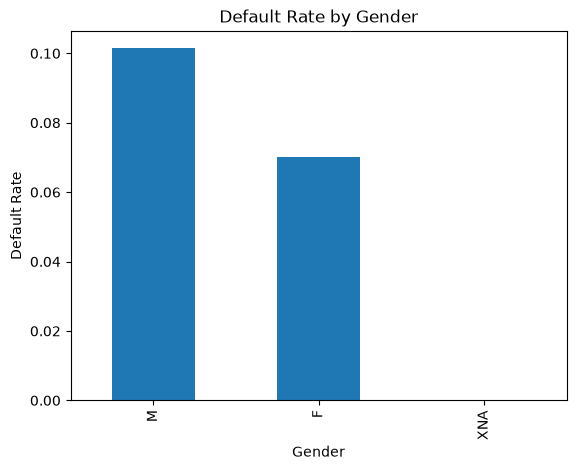

In [32]:
gender_default.plot(kind="bar")

plt.title("Default Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Default Rate")
plt.show()

## Default Rate by Education Type

This analysis checks whether repayment difficulty differs across applicant education categories.

In [33]:
education_default = app_train.groupby("NAME_EDUCATION_TYPE")[target].mean().sort_values(ascending=False)

education_default

NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / secondary special    0.089399
Incomplete higher                0.084850
Higher education                 0.053551
Academic degree                  0.018293
Name: TARGET, dtype: float64

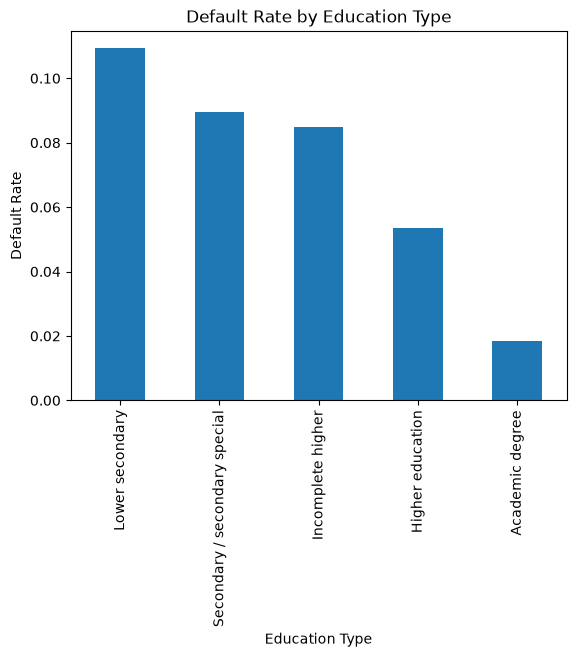

In [34]:
education_default.plot(kind="bar")

plt.title("Default Rate by Education Type")
plt.xlabel("Education Type")
plt.ylabel("Default Rate")
plt.show()

## Default Rate by Family Status

This analysis checks whether marital or family status is associated with repayment difficulty.

In [35]:
family_default = app_train.groupby("NAME_FAMILY_STATUS")[target].mean().sort_values(ascending=False)

family_default

NAME_FAMILY_STATUS
Civil marriage          0.099446
Single / not married    0.098077
Separated               0.081942
Married                 0.075599
Widow                   0.058242
Unknown                 0.000000
Name: TARGET, dtype: float64

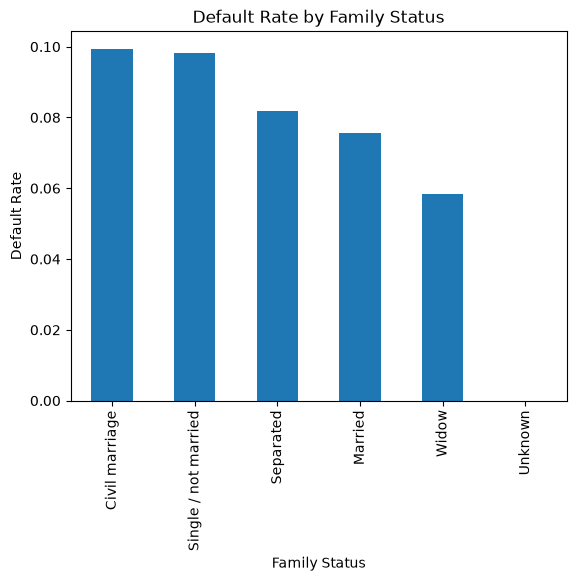

In [36]:
family_default.plot(kind="bar")

plt.title("Default Rate by Family Status")
plt.xlabel("Family Status")
plt.ylabel("Default Rate")
plt.show()

## Default Rate by Income Bucket

Income is a continuous variable, so it is divided into buckets. This helps compare default rates across income groups.

In [37]:
app_train["income_bucket"] = pd.qcut(
    app_train["AMT_INCOME_TOTAL"],
    q=5,
    duplicates="drop"
)

income_default = app_train.groupby("income_bucket")[target].mean()

income_default

C:\Users\gsard\AppData\Local\Temp\ipykernel_32720\1253765492.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train["income_bucket"] = pd.qcut(


income_bucket
(25649.999, 99000.0]       0.082062
(99000.0, 135000.0]        0.085883
(135000.0, 162000.0]       0.086847
(162000.0, 225000.0]       0.080569
(225000.0, 117000000.0]    0.065198
Name: TARGET, dtype: float64

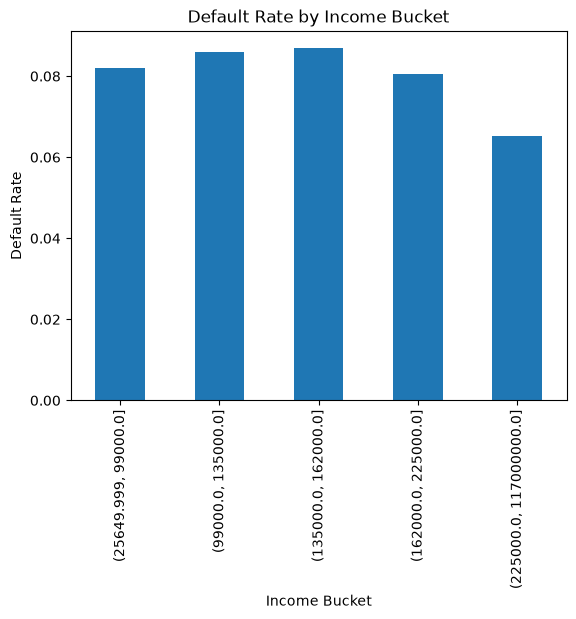

In [38]:
income_default.plot(kind="bar")

plt.title("Default Rate by Income Bucket")
plt.xlabel("Income Bucket")
plt.ylabel("Default Rate")
plt.show()

## Default Rate by Credit Amount Bucket

Credit amount is divided into buckets to analyse whether larger loan amounts are associated with higher repayment difficulty.

In [39]:
app_train["credit_bucket"] = pd.qcut(
    app_train["AMT_CREDIT"],
    q=5,
    duplicates="drop"
)

credit_default = app_train.groupby("credit_bucket")[target].mean()

credit_default

C:\Users\gsard\AppData\Local\Temp\ipykernel_32720\3803500823.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train["credit_bucket"] = pd.qcut(


credit_bucket
(44999.999, 254700.0]    0.072376
(254700.0, 432000.0]     0.091724
(432000.0, 604152.0]     0.100549
(604152.0, 900000.0]     0.078549
(900000.0, 4050000.0]    0.060752
Name: TARGET, dtype: float64

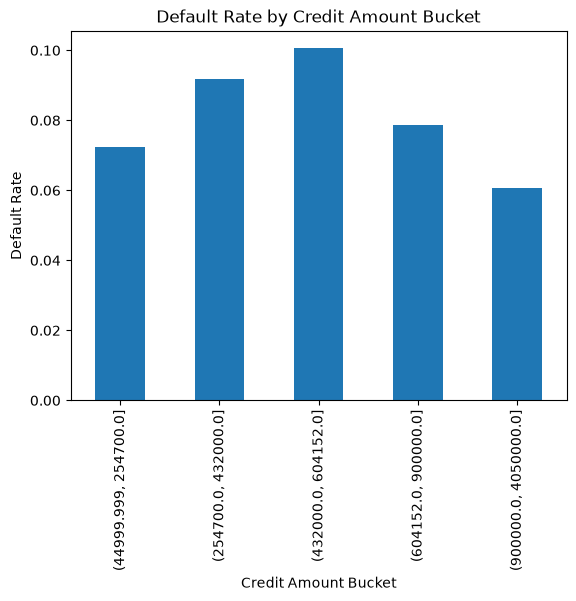

In [40]:
credit_default.plot(kind="bar")

plt.title("Default Rate by Credit Amount Bucket")
plt.xlabel("Credit Amount Bucket")
plt.ylabel("Default Rate")
plt.show()

## Default Rate by Age Group

The `DAYS_BIRTH` column is stored as negative days before the application date. It is converted into applicant age in years.

In [41]:
app_train["AGE_YEARS"] = -app_train["DAYS_BIRTH"] / 365

app_train["age_group"] = pd.cut(
    app_train["AGE_YEARS"],
    bins=[20, 30, 40, 50, 60, 70],
    labels=["20-30", "30-40", "40-50", "50-60", "60-70"]
)

age_default = app_train.groupby("age_group")[target].mean()

age_default

C:\Users\gsard\AppData\Local\Temp\ipykernel_32720\1768718409.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train["AGE_YEARS"] = -app_train["DAYS_BIRTH"] / 365
C:\Users\gsard\AppData\Local\Temp\ipykernel_32720\1768718409.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train["age_group"] = pd.cut(


age_group
20-30    0.114569
30-40    0.095835
40-50    0.076508
50-60    0.061297
60-70    0.049214
Name: TARGET, dtype: float64

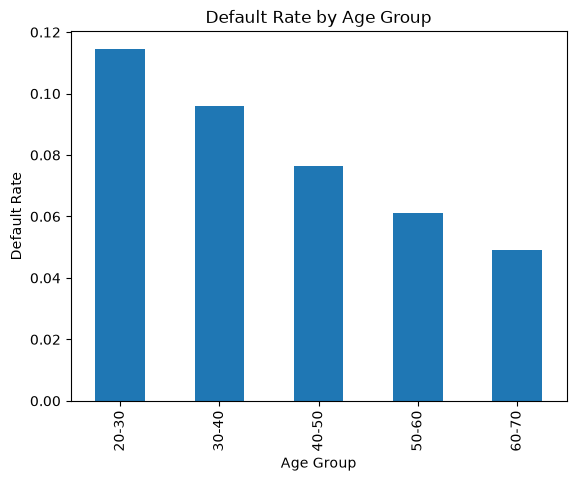

In [42]:
age_default.plot(kind="bar")

plt.title("Default Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Default Rate")
plt.show()

## Default Rate by Employment Length

The `DAYS_EMPLOYED` column is converted into years of employment. Abnormal values are replaced with missing values before analysis.

In [43]:
app_train["DAYS_EMPLOYED_CLEAN"] = app_train["DAYS_EMPLOYED"].replace(365243, np.nan)

app_train["EMPLOYMENT_YEARS"] = -app_train["DAYS_EMPLOYED_CLEAN"] / 365

app_train["employment_group"] = pd.cut(
    app_train["EMPLOYMENT_YEARS"],
    bins=[0, 1, 3, 5, 10, 20, 50],
    labels=["0-1", "1-3", "3-5", "5-10", "10-20", "20+"]
)

employment_default = app_train.groupby("employment_group")[target].mean()

employment_default

C:\Users\gsard\AppData\Local\Temp\ipykernel_32720\4224101488.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train["DAYS_EMPLOYED_CLEAN"] = app_train["DAYS_EMPLOYED"].replace(365243, np.nan)
C:\Users\gsard\AppData\Local\Temp\ipykernel_32720\4224101488.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app_train["EMPLOYMENT_YEARS"] = -app_train["DAYS_EMPLOYED_CLEAN"] / 365
C:\Users\gsard\AppData\Local\Temp\ipykernel_32720\4224101488.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

employment_group
0-1      0.109685
1-3      0.110733
3-5      0.096741
5-10     0.073714
10-20    0.055133
20+      0.041892
Name: TARGET, dtype: float64

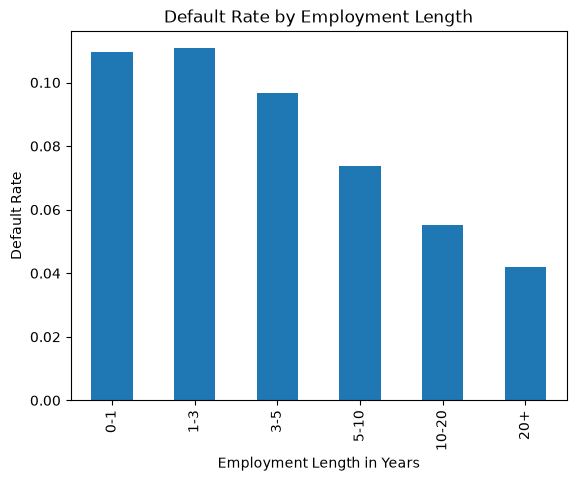

In [44]:
employment_default.plot(kind="bar")

plt.title("Default Rate by Employment Length")
plt.xlabel("Employment Length in Years")
plt.ylabel("Default Rate")
plt.show()

## Default Rate by Occupation Type

This analysis checks whether default risk differs by applicant occupation type.

In [45]:
occupation_default = app_train.groupby("OCCUPATION_TYPE")[target].mean().sort_values(ascending=False)

occupation_default

OCCUPATION_TYPE
Low-skill Laborers       0.171524
Drivers                  0.113261
Waiters/barmen staff     0.112760
Security staff           0.107424
Laborers                 0.105788
Cooking staff            0.104440
Sales staff              0.096318
Cleaning staff           0.096067
Realty agents            0.078562
Secretaries              0.070498
Medicine staff           0.067002
Private service staff    0.065988
IT staff                 0.064639
HR staff                 0.063943
Core staff               0.063040
Managers                 0.062140
High skill tech staff    0.061599
Accountants              0.048303
Name: TARGET, dtype: float64

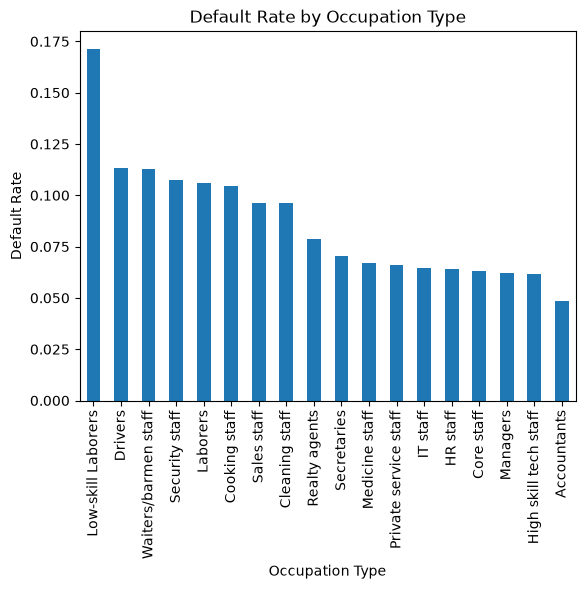

In [46]:
occupation_default.plot(kind="bar")

plt.title("Default Rate by Occupation Type")
plt.xlabel("Occupation Type")
plt.ylabel("Default Rate")
plt.show()

## EDA Business Observations

The exploratory analysis shows that applicant characteristics are associated with repayment difficulty.

Categorical variables such as contract type, gender, education type, family status, and occupation type show differences in default rates across groups.

Numerical variables such as income, credit amount, age, and employment length also help explain borrower risk when converted into meaningful buckets.

These insights will be useful for feature engineering and model building in the next stage of the project.

The next step is to analyse missing values and feature types before building the baseline Probability of Default model.